# Sentiment Analysis for E-Commerce Customer Feedback  

This notebook builds a complete sentiment analysis pipeline for **customer feedback in the hospitality industry**.  
It uses the **Yelp Review Full** dataset and compares:

1. **Multinomial Naive Bayes + TF-IDF**
2. **Linear SVM + TF-IDF**
3. **DistilBERT Transformer fine-tuning**

The notebook includes:

- dataset justification and industry alignment
- careful preprocessing with rationale
- balanced sentiment labeling
- multiple model comparisons
- detailed evaluation and error analysis
- business interpretation of the results

---

## How to run in Google Colab

1. Open this notebook in **Google Colab**
2. Set runtime to **GPU** for the transformer section  
   - `Runtime` → `Change runtime type` → `T4 GPU`
3. Run all cells from top to bottom
4. If you want a faster run, reduce the sample sizes in the configuration cell
5. The classical ML models run on CPU; GPU mainly helps the transformer section

---

## Dataset choice

This project uses a **Yelp Review Full dataset**, which contains large-scale customer feedback from the hospitality and service industry, including restaurants, businesses, and local services.

This dataset is well-suited for sentiment analysis because:

- it consists of real-world customer reviews
- it includes 1–5 star ratings, enabling structured sentiment labeling
- it reflects diverse customer experiences, from highly negative to highly positive

To align with business-oriented sentiment analysis, star ratings are mapped into three categories:

- **Negative**:  1–2 stars
- **Neutral**: 3 stars
- **Positive**: 4–5 stars

This mapping provides a practical abstraction for business decision-making while preserving meaningful sentiment distinctions.

In [1]:
# Install required packages
!pip -q install datasets transformers accelerate evaluate sentencepiece scikit-learn matplotlib pandas numpy tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00


In [2]:
import os
import re
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
set_seed(SEED)

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Dataset

This notebook uses the Yelp Review:

- it contains **real customer feedback**
- it belongs directly to the **hospitality industry**
- it provides **1–5 star labels**, which can be transformed into sentiment classes
- it is large enough to support both classical machine learning and transformer-based modeling
- it contains product review text that resembles practical business feedback data

To improve reproducibility in Colab, this notebook works from the public `datasets` library instead of requiring a Kaggle API key.


In [ ]:
# Configuration
TRAIN_PER_CLASS = 6000
VAL_PER_CLASS = 1000
TEST_PER_CLASS = 1000

# Transformer training settings
TRANSFORMER_MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256
NUM_EPOCHS = 1
BATCH_SIZE = 16
LEARNING_RATE = 2e-5

print({
    "TRAIN_PER_CLASS": TRAIN_PER_CLASS,
    "VAL_PER_CLASS": VAL_PER_CLASS,
    "TEST_PER_CLASS": TEST_PER_CLASS,
    "TRANSFORMER_MODEL_NAME": TRANSFORMER_MODEL_NAME,
    "NUM_EPOCHS": NUM_EPOCHS,
    "BATCH_SIZE": BATCH_SIZE
})


{'TRAIN_PER_CLASS': 6000, 'VAL_PER_CLASS': 1000, 'TEST_PER_CLASS': 1000, 'TRANSFORMER_MODEL_NAME': 'distilbert-base-uncased', 'NUM_EPOCHS': 1, 'BATCH_SIZE': 16}


In [9]:
# Load dataset
dataset = load_dataset("yelp_review_full")
dataset


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})

In [10]:
# Peek at the schema and a few examples
print(dataset)
print("\nColumns:", dataset["train"].column_names)
pd.DataFrame(dataset["train"][:5])


DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})

Columns: ['label', 'text']


,label,text
0,4,dr. goldberg offers everything i look for in a...
1,1,"Unfortunately, the frustration of being Dr. Go..."
2,3,Been going to Dr. Goldberg for over 10 years. ...
3,3,Got a letter in the mail last week that said D...
4,0,I don't know what Dr. Goldberg was like before...


## 2. Target construction

The raw dataset includes **star ratings from 1 to 5**, which serve as a proxy for customer sentiment.  

For this project, these ratings are transformed into **three interpretable sentiment categories**:

- **Negative**: 1–2 stars  
- **Neutral**: 3 stars  
- **Positive**: 4–5 stars  

This transformation is well-aligned with business applications, where organizations typically distinguish between:
- dissatisfied customers who may require intervention  
- neutral or mixed-feedback customers who are potential conversion opportunities  
- satisfied customers who reflect positive service outcomes  

The dataset provides a single **review text field**, which is used directly as input to the models.

Unlike datasets with separate title and body fields, no merging is required, ensuring a simpler and more consistent preprocessing pipeline while still preserving sufficient contextual information for sentiment classification.

This labeling strategy balances interpretability and modeling simplicity while preserving meaningful sentiment distinctions for downstream analysis.

In [12]:
LABEL_MAP = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

def stars_to_sentiment(stars):
    if stars <= 2:
        return 0
    elif stars == 3:
        return 1
    else:
        return 2

def clean_for_model(text):
    if text is None:
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def build_dataframe(hf_split):
    df = pd.DataFrame(hf_split)

    df["stars"] = df["label"] + 1   # convert 0–4 → 1–5
    df["text"] = df["text"].apply(clean_for_model)

    df = df[df["text"].str.len() > 0].copy()

    df["label"] = df["stars"].apply(stars_to_sentiment)
    df["sentiment"] = df["label"].map(LABEL_MAP)

    return df[["text", "stars", "label", "sentiment"]]

train_df_full = build_dataframe(dataset["train"])
test_df_full = build_dataframe(dataset["test"])

from sklearn.model_selection import train_test_split
train_df_full, val_df_full = train_test_split(
    train_df_full, test_size=0.1, random_state=42, stratify=train_df_full["label"]
)

print("Train:", train_df_full.shape)
print("Validation:", val_df_full.shape)
print("Test:", test_df_full.shape)

train_df_full.head()

Train: (585000, 4)
Validation: (65000, 4)
Test: (50000, 4)


,text,stars,label,sentiment
202086,This is my second time eating here. Both exper...,5,2,positive
353901,Newington Coffee Shop is situated in the centr...,3,1,neutral
246289,Went to PIR for the second to last Nascar race...,5,2,positive
201605,The first time I came here was for the Lupe Fi...,5,2,positive
312516,Price are outrageous. Don't order the hand rol...,2,0,negative


In [13]:
def summarize_split(name, df):
    print(f"\n{name} split")
    print("-" * 40)

    print(f"Rows: {len(df):,}")

    print("\nSentiment distribution (count):")
    print(df["sentiment"].value_counts().sort_index())

    print("\nSentiment distribution (%):")
    print((df["sentiment"].value_counts(normalize=True) * 100).round(2).sort_index())

    print("\nStar distribution:")
    print(df["stars"].value_counts().sort_index())


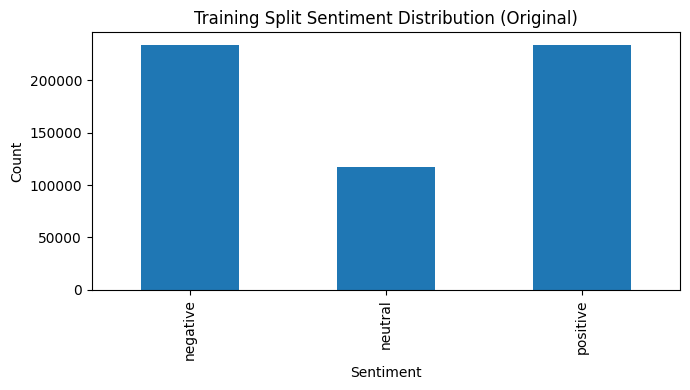

In [14]:
# Visualize class distribution before balancing
fig = plt.figure(figsize=(7, 4))
train_df_full["sentiment"].value_counts().sort_index().plot(kind="bar")
plt.title("Training Split Sentiment Distribution (Original)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 3. Balanced sampling strategy

Public review datasets are often **class-imbalanced**, with positive reviews dominating.  
If left untouched, a model may appear strong by mostly predicting positive sentiment.

To produce a fairer academic comparison, this notebook creates a **balanced subset** from each split:
- equal counts of negative, neutral, and positive examples
- consistent sample sizes for model comparison
- faster runtime in Colab
- cleaner interpretation of macro precision, recall, and F1

This does **not** mean class imbalance is unimportant.  
In the final discussion section of the paper, you should note that real-world production data is usually imbalanced and may require additional methods such as class weights, threshold tuning, or cost-sensitive learning.


In [15]:
def balanced_sample(df, n_per_class, seed=SEED):
    pieces = []
    for label_id in sorted(df["label"].unique()):
        subset = df[df["label"] == label_id]
        if len(subset) < n_per_class:
            raise ValueError(
                f"Not enough samples for label {label_id}. "
                f"Needed {n_per_class}, found {len(subset)}."
            )
        pieces.append(subset.sample(n=n_per_class, random_state=seed))
    out = pd.concat(pieces).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

train_df = balanced_sample(train_df_full, TRAIN_PER_CLASS)
val_df = balanced_sample(val_df_full, VAL_PER_CLASS)
test_df = balanced_sample(test_df_full, TEST_PER_CLASS)

print(train_df["sentiment"].value_counts())
print(val_df["sentiment"].value_counts())
print(test_df["sentiment"].value_counts())


sentiment
negative    6000
neutral     6000
positive    6000
Name: count, dtype: int64
sentiment
neutral     1000
negative    1000
positive    1000
Name: count, dtype: int64
sentiment
neutral     1000
negative    1000
positive    1000
Name: count, dtype: int64


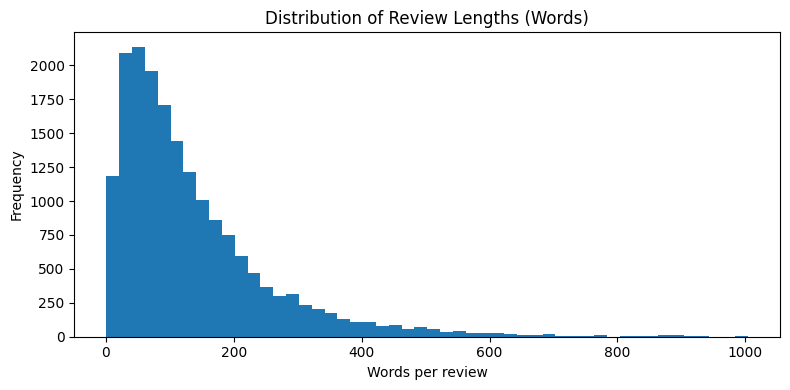

,char_len,word_len
count,18000.000000,18000.000000
mean,739.597222,135.858722
std,664.962474,121.887941
min,5.000000,1.000000
25%,287.000000,53.000000
50%,547.000000,101.000000
75%,973.000000,179.000000
max,5022.000000,1004.000000


In [16]:
# Review length analysis
train_df["char_len"] = train_df["text"].str.len()
train_df["word_len"] = train_df["text"].str.split().str.len()

fig = plt.figure(figsize=(8, 4))
plt.hist(train_df["word_len"], bins=50)
plt.title("Distribution of Review Lengths (Words)")
plt.xlabel("Words per review")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

train_df[["char_len", "word_len"]].describe()


### Exploratory Data Analysis

The dataset exhibits a **right-skewed distribution of review lengths**, with a median of approximately 101 words and a mean of 136 words. While most reviews are relatively short (under 200 words), a small number of reviews extend beyond 500 words, forming a long tail. This pattern is common in customer feedback data and reflects varying levels of user engagement.

The presence of extremely long reviews suggests potential noise and variability in linguistic structure, which can impact model performance. However, transformer-based models are generally more robust to such variation compared to traditional bag-of-words approaches.

In terms of sentiment distribution, the dataset is **naturally imbalanced**, with positive and negative reviews significantly outnumbering neutral reviews. This imbalance can bias models toward majority classes if not addressed.

To mitigate this, a **balanced sampling strategy** is applied in subsequent steps, ensuring equal representation of negative, neutral, and positive classes. Additionally, evaluation metrics such as **macro-averaged F1-score** are used to provide a more reliable assessment across all sentiment categories.

## 4. Preprocessing rationale

### For classical ML models
The notebook uses **light text normalization** rather than aggressive cleaning.

Steps:
- merge review title and body
- remove extra whitespace
- lowercase handled inside vectorization
- use TF-IDF with unigrams and bigrams
- remove English stop words
- keep negation-bearing words where possible through n-grams
- avoid heavy punctuation stripping rules that may remove useful signals

Why this is reasonable:
- customer-review sentiment often depends on short phrases such as **“not good”**, **“very disappointed”**, or **“works perfectly”**
- TF-IDF with **1–2 grams** captures many of these patterns well
- over-cleaning can destroy sentiment-bearing structure

### For the transformer
The transformer uses the **raw normalized text** and relies on its pretrained tokenizer.
That is the preferred practice because transformer tokenizers are designed to preserve useful contextual information without manual stemming or lemmatization.


In [17]:
# Classical ML pipelines
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("clf", MultinomialNB(alpha=0.5))
])

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("clf", LinearSVC(C=1.0))
])

X_train, y_train = train_df["text"], train_df["label"]
X_val, y_val = val_df["text"], val_df["label"]
X_test, y_test = test_df["text"], test_df["label"]

print("Prepared train/validation/test splits for classical models.")


Prepared train/validation/test splits for classical models.


In [18]:
def compute_metrics_from_predictions(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision_macro": round(precision_macro, 4),
        "Recall_macro": round(recall_macro, 4),
        "F1_macro": round(f1_macro, 4),
        "Precision_weighted": round(precision_weighted, 4),
        "Recall_weighted": round(recall_weighted, 4),
        "F1_weighted": round(f1_weighted, 4)
    }

results = []


In [19]:
# Train and evaluate Multinomial Naive Bayes
nb_pipeline.fit(X_train, y_train)
nb_val_pred = nb_pipeline.predict(X_val)
nb_test_pred = nb_pipeline.predict(X_test)

nb_metrics = compute_metrics_from_predictions(y_test, nb_test_pred, "TF-IDF + MultinomialNB")
results.append(nb_metrics)

print("Validation Classification Report: Naive Bayes")
print(classification_report(y_val, nb_val_pred, target_names=[LABEL_MAP[i] for i in sorted(LABEL_MAP)]))

print("Test Classification Report: Naive Bayes")
print(classification_report(y_test, nb_test_pred, target_names=[LABEL_MAP[i] for i in sorted(LABEL_MAP)]))


Validation Classification Report: Naive Bayes
              precision    recall  f1-score   support

    negative       0.74      0.75      0.74      1000
     neutral       0.59      0.66      0.62      1000
    positive       0.79      0.70      0.74      1000

    accuracy                           0.70      3000
   macro avg       0.71      0.70      0.70      3000
weighted avg       0.71      0.70      0.70      3000

Test Classification Report: Naive Bayes
              precision    recall  f1-score   support

    negative       0.72      0.72      0.72      1000
     neutral       0.56      0.64      0.60      1000
    positive       0.78      0.67      0.72      1000

    accuracy                           0.68      3000
   macro avg       0.69      0.68      0.68      3000
weighted avg       0.69      0.68      0.68      3000



In [20]:
# Train and evaluate Linear SVM
svm_pipeline.fit(X_train, y_train)
svm_val_pred = svm_pipeline.predict(X_val)
svm_test_pred = svm_pipeline.predict(X_test)

svm_metrics = compute_metrics_from_predictions(y_test, svm_test_pred, "TF-IDF + LinearSVC")
results.append(svm_metrics)

print("Validation Classification Report: Linear SVM")
print(classification_report(y_val, svm_val_pred, target_names=[LABEL_MAP[i] for i in sorted(LABEL_MAP)]))

print("Test Classification Report: Linear SVM")
print(classification_report(y_test, svm_test_pred, target_names=[LABEL_MAP[i] for i in sorted(LABEL_MAP)]))


Validation Classification Report: Linear SVM
              precision    recall  f1-score   support

    negative       0.75      0.77      0.76      1000
     neutral       0.61      0.54      0.57      1000
    positive       0.72      0.78      0.75      1000

    accuracy                           0.70      3000
   macro avg       0.69      0.70      0.69      3000
weighted avg       0.69      0.70      0.69      3000

Test Classification Report: Linear SVM
              precision    recall  f1-score   support

    negative       0.74      0.74      0.74      1000
     neutral       0.60      0.57      0.59      1000
    positive       0.73      0.76      0.75      1000

    accuracy                           0.69      3000
   macro avg       0.69      0.69      0.69      3000
weighted avg       0.69      0.69      0.69      3000



In [21]:
# Compare classical model performance
results_df = pd.DataFrame(results).sort_values("F1_macro", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted
0,TF-IDF + LinearSVC,0.693,0.6911,0.693,0.6918,0.6911,0.693,0.6918
1,TF-IDF + MultinomialNB,0.677,0.6873,0.677,0.6799,0.6873,0.677,0.6799


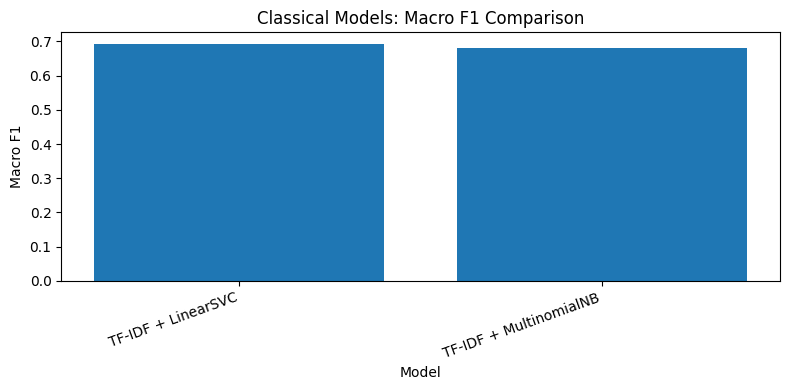

In [22]:
# Plot classical model comparison
fig = plt.figure(figsize=(8, 4))
plt.bar(results_df["Model"], results_df["F1_macro"])
plt.title("Classical Models: Macro F1 Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


<Figure size 500x400 with 0 Axes>

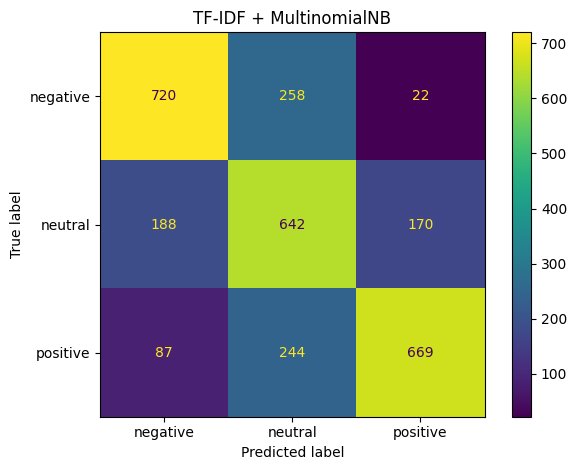

<Figure size 500x400 with 0 Axes>

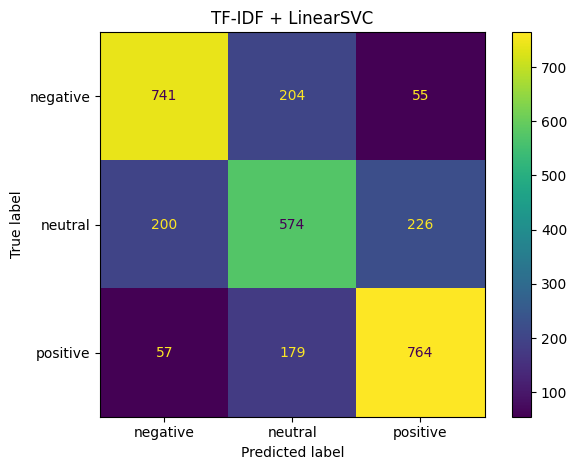

In [23]:
# Confusion matrices for classical models
for model_name, preds in [
    ("TF-IDF + MultinomialNB", nb_test_pred),
    ("TF-IDF + LinearSVC", svm_test_pred),
]:
    fig = plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[LABEL_MAP[i] for i in sorted(LABEL_MAP)])
    disp.plot(values_format="d")
    plt.title(model_name)
    plt.tight_layout()
    plt.show()


### Confusion Matrix Analysis

The confusion matrices for both models reveal a consistent pattern of misclassification centered around the neutral class. In particular, most errors occur when negative or positive reviews are incorrectly classified as neutral, and vice versa. Importantly, direct misclassification between negative and positive classes is relatively rare, indicating that both models effectively capture strongly polarized sentiment.

Comparing the two models, Multinomial Naive Bayes demonstrates a higher tendency to classify reviews as neutral, as evidenced by a larger number of negative-to-neutral and positive-to-neutral misclassifications. This suggests that Naive Bayes behaves more conservatively, defaulting to the neutral class when confidence is low.

In contrast, the Linear SVM model produces more balanced predictions across all classes. While it slightly underperforms Naive Bayes in correctly identifying neutral reviews, it reduces over-prediction of the neutral class and improves discrimination between positive and negative sentiment. This results in a higher macro-averaged F1-score.

These findings highlight a key trade-off: Naive Bayes favors stability and neutral classification, whereas Linear SVM achieves better class separation and overall performance.

## 5. Interpreting feature importance for the linear SVM

Linear SVM is often a strong baseline for sentiment analysis with TF-IDF.  
One advantage is interpretability: we can inspect which terms push predictions toward a given sentiment class.

This helps transform the project from pure prediction into **business insight**:
- what words tend to signal dissatisfaction?
- what phrases are associated with positive experiences?
- does the neutral class capture mixed or uncertain language?


In [24]:
# Inspect top weighted terms from the Linear SVM
tfidf = svm_pipeline.named_steps["tfidf"]
svm_model = svm_pipeline.named_steps["clf"]

feature_names = np.array(tfidf.get_feature_names_out())
coef = svm_model.coef_

def show_top_terms_for_class(class_index, top_n=15):
    top_idx = np.argsort(coef[class_index])[-top_n:][::-1]
    return pd.DataFrame({
        "term": feature_names[top_idx],
        "weight": coef[class_index][top_idx]
    })

for i in sorted(LABEL_MAP):
    print(f"\nTop positive terms for class: {LABEL_MAP[i]}")
    display(show_top_terms_for_class(i, top_n=15))



Top positive terms for class: negative


,term,weight
0,worst,3.853032
1,horrible,3.478765
2,bland,2.741595
3,told,2.675507
4,terrible,2.618278
5,dirty,2.320100
6,soggy,2.220182
7,rude,2.196665
8,poor,2.174404
9,sorry,2.165769



Top positive terms for class: neutral


,term,weight
0,stars,3.002070
1,decent,2.863350
2,good,2.415060
3,bit,2.354381
4,alright,2.134956
5,nhowever,2.061392
6,ok,1.934574
7,average,1.775472
8,nbut,1.664738
9,good great,1.645302



Top positive terms for class: positive


,term,weight
0,amazing,3.731012
1,great,3.712211
2,best,3.401736
3,delicious,3.386371
4,awesome,2.983249
5,love,2.924222
6,perfect,2.799515
7,excellent,2.652936
8,favorite,2.359795
9,loved,2.262248


## 6. Transformer model: DistilBERT fine-tuning

To satisfy the requirement for advanced modeling, this notebook also fine-tunes **DistilBERT**, a compact transformer model well-suited for Colab.

Why DistilBERT:
- much more context-aware than bag-of-words methods
- efficient enough for classroom environments
- strong baseline for review sentiment tasks
- easier to train in Colab than larger transformer families

Important note:
- Classical models use manually engineered TF-IDF features
- DistilBERT learns contextual representations directly from text
- This makes the comparison academically meaningful


In [25]:
# Convert balanced pandas DataFrames to Hugging Face datasets
hf_train = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
hf_val = Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False)
hf_test = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)

hf_datasets = DatasetDict({
    "train": hf_train,
    "validation": hf_val,
    "test": hf_test
})

tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized = hf_datasets.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 18000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3000
    })
})

In [26]:
# Define evaluation metrics for the Trainer
def trainer_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }


In [29]:
# Initialize model
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    TRANSFORMER_MODEL_NAME,
    num_labels=3
)

training_args = TrainingArguments(
    output_dir="./distilbert_sentiment_output",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    do_eval=True,
    logging_steps=100,
    report_to="none"
)

trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=trainer_compute_metrics
)
print("Trainer initialized.")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer initialized.


In [30]:
# Train the transformer
trainer.train()


Step,Training Loss
100,0.880418
200,0.679133
300,0.650844
400,0.646901
500,0.623568
600,0.615334
700,0.652108
800,0.593672
900,0.588689
1000,0.578205


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1125, training_loss=0.642483763800727, metrics={'train_runtime': 424.0442, 'train_samples_per_second': 42.448, 'train_steps_per_second': 2.653, 'total_flos': 1189636409515968.0, 'train_loss': 0.642483763800727, 'epoch': 1.0})

In [31]:
# Evaluate on validation and test sets
val_metrics = trainer.evaluate(tokenized["validation"])
test_metrics = trainer.evaluate(tokenized["test"])

print("Validation metrics:", val_metrics)
print("Test metrics:", test_metrics)


Validation metrics: {'eval_loss': 0.563927948474884, 'eval_accuracy': 0.7573333333333333, 'eval_precision_macro': 0.757489899125234, 'eval_recall_macro': 0.7573333333333334, 'eval_f1_macro': 0.7574099733851951, 'eval_precision_weighted': 0.7574898991252341, 'eval_recall_weighted': 0.7573333333333333, 'eval_f1_weighted': 0.7574099733851951, 'eval_runtime': 21.3501, 'eval_samples_per_second': 140.515, 'eval_steps_per_second': 8.806, 'epoch': 1.0}
Test metrics: {'eval_loss': 0.5623001456260681, 'eval_accuracy': 0.75, 'eval_precision_macro': 0.7542867528559477, 'eval_recall_macro': 0.75, 'eval_f1_macro': 0.7516720194740337, 'eval_precision_weighted': 0.7542867528559477, 'eval_recall_weighted': 0.75, 'eval_f1_weighted': 0.7516720194740337, 'eval_runtime': 21.924, 'eval_samples_per_second': 136.836, 'eval_steps_per_second': 8.575, 'epoch': 1.0}


In [34]:
# Generate transformer predictions for the test set
pred_output = trainer.predict(tokenized["test"])
transformer_test_pred = np.argmax(pred_output.predictions, axis=-1)

transformer_metrics = compute_metrics_from_predictions(
    y_true=test_df["label"].to_numpy(),
    y_pred=transformer_test_pred,
    model_name="DistilBERT fine-tuned"
)

results.append(transformer_metrics)
results_df = pd.DataFrame(results).sort_values("F1_macro", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted
0,DistilBERT fine-tuned,0.750,0.7543,0.750,0.7517,0.7543,0.750,0.7517
1,TF-IDF + LinearSVC,0.693,0.6911,0.693,0.6918,0.6911,0.693,0.6918
2,TF-IDF + MultinomialNB,0.677,0.6873,0.677,0.6799,0.6873,0.677,0.6799


<Figure size 500x400 with 0 Axes>

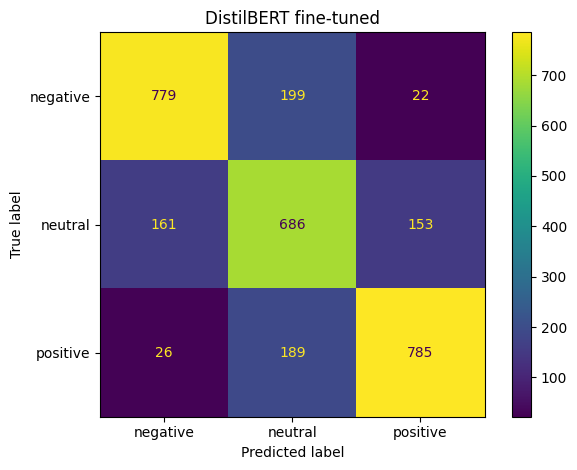

In [35]:
# Confusion matrix for DistilBERT
fig = plt.figure(figsize=(5, 4))
cm = confusion_matrix(test_df["label"], transformer_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[LABEL_MAP[i] for i in sorted(LABEL_MAP)])
disp.plot(values_format="d")
plt.title("DistilBERT fine-tuned")
plt.tight_layout()
plt.show()


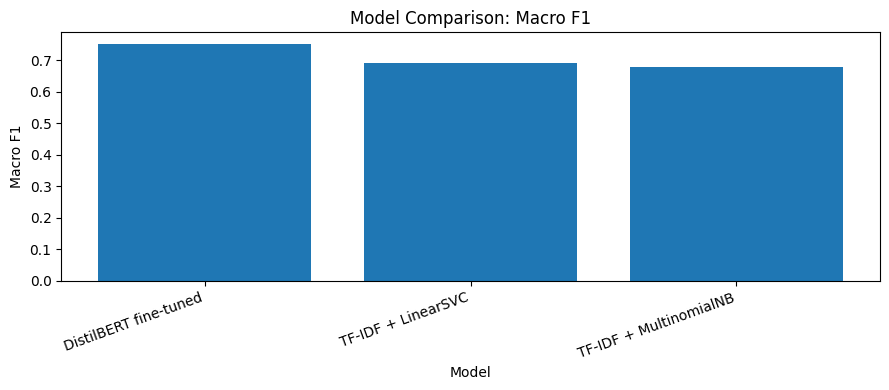

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted
0,DistilBERT fine-tuned,0.750,0.7543,0.750,0.7517,0.7543,0.750,0.7517
1,TF-IDF + LinearSVC,0.693,0.6911,0.693,0.6918,0.6911,0.693,0.6918
2,TF-IDF + MultinomialNB,0.677,0.6873,0.677,0.6799,0.6873,0.677,0.6799


In [36]:
# Final model comparison plot
fig = plt.figure(figsize=(9, 4))
plot_df = results_df.sort_values("F1_macro", ascending=False)
plt.bar(plot_df["Model"], plot_df["F1_macro"])
plt.title("Model Comparison: Macro F1")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

results_df


The DistilBERT model achieves a macro F1-score of approximately 0.75, representing a substantial improvement over classical approaches. This performance gain demonstrates the importance of contextual representation in sentiment classification, particularly for capturing nuanced linguistic patterns.

However, the model does not achieve near-perfect performance, which reflects the inherent complexity of the task rather than model deficiency. In particular, the presence of a neutral class introduces significant ambiguity, as such instances often contain mixed or weakly expressed sentiment signals. This limits the achievable upper bound for classification accuracy.

The results suggest that while transformer-based models significantly outperform traditional methods, sentiment classification in real-world customer feedback remains a fundamentally challenging problem. Improvements beyond this level may require more granular labeling schemes, such as aspect-based sentiment analysis, or the incorporation of additional contextual signals beyond text alone.

## 7. Error analysis

This section inspects misclassified examples to understand:

- whether neutral reviews are ambiguous
- whether short reviews are harder to classify
- whether sarcasm, mixed sentiment, or product-specific wording causes confusion
- whether errors matter differently for business use cases


In [37]:
# Error analysis for the best-performing model
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

if best_model_name == "DistilBERT fine-tuned":
    best_preds = transformer_test_pred
elif best_model_name == "TF-IDF + LinearSVC":
    best_preds = svm_test_pred
else:
    best_preds = nb_test_pred

error_df = test_df.copy().reset_index(drop=True)
error_df["pred_label"] = best_preds
error_df["pred_sentiment"] = error_df["pred_label"].map(LABEL_MAP)
error_df["correct"] = error_df["label"] == error_df["pred_label"]

misclassified = error_df[~error_df["correct"]].copy()
print("Number of misclassified examples:", len(misclassified))
misclassified[["text", "sentiment", "pred_sentiment"]].head(15)


Best model: DistilBERT fine-tuned
Number of misclassified examples: 750


,text,sentiment,pred_sentiment
2,Oh Jackalope Jack's. I've been here a few time...,neutral,negative
4,Ugh. So Bloom is owned by Food Lion--except Bl...,positive,negative
8,This is a big place.. but rooms are just okay....,negative,neutral
12,I have going there for couple years and there ...,negative,neutral
13,Homestyle uuber sized portions! Check out my h...,neutral,negative
15,This review is purely on the management and cu...,negative,neutral
16,This place rocks! I love the variety of music ...,neutral,positive
22,They don't carry bagel chips anymore and every...,negative,neutral
24,friendly folks and unusual items. I've always ...,neutral,positive
31,I was so so happy with this place. Amazing Lob...,neutral,negative


In [38]:
# View examples by confusion type
def show_confusion_examples(actual_label, predicted_label, n=5):
    subset = misclassified[
        (misclassified["label"] == actual_label) &
        (misclassified["pred_label"] == predicted_label)
    ][["text", "sentiment", "pred_sentiment"]].head(n)
    print(f"Actual={LABEL_MAP[actual_label]}, Predicted={LABEL_MAP[predicted_label]}")
    display(subset)

for a in sorted(LABEL_MAP):
    for p in sorted(LABEL_MAP):
        if a != p:
            show_confusion_examples(a, p, n=3)


Actual=negative, Predicted=neutral


,text,sentiment,pred_sentiment
8,This is a big place.. but rooms are just okay....,negative,neutral
12,I have going there for couple years and there ...,negative,neutral
15,This review is purely on the management and cu...,negative,neutral


Actual=negative, Predicted=positive


,text,sentiment,pred_sentiment
42,Heuuu... Que dire? Le resto est tr\u00e8s viei...,negative,positive
136,an absolute atrocity to all that is good and e...,negative,positive
462,This is a hard review to write. So I'll need t...,negative,positive


Actual=neutral, Predicted=negative


...

,text,sentiment,pred_sentiment
16,This place rocks! I love the variety of music ...,neutral,positive
24,friendly folks and unusual items. I've always ...,neutral,positive
45,i have never had an issue here. i like it,neutral,positive


Actual=positive, Predicted=negative


,text,sentiment,pred_sentiment
4,Ugh. So Bloom is owned by Food Lion--except Bl...,positive,negative
48,"Darn it. All this time, I was excited to have ...",positive,negative
148,Well I went in here looking for gifts for othe...,positive,negative


Actual=positive, Predicted=neutral


,text,sentiment,pred_sentiment
46,"Pretty good sushi bar, we got here around 9:00...",positive,neutral
53,"Being from Colorado, we read beforehand that t...",positive,neutral
58,"I went to this place alone, around 3 PM on a T...",positive,neutral


## 8. Performance Improvement Experiment

The initial transformer results provide a strong baseline, but additional gains may be possible through targeted fine-tuning adjustments. Rather than changing the overall problem setup, this section performs a second round of training to evaluate whether performance can be improved through better hyperparameter choices and a stronger transformer backbone.

The main goals of this follow-up experiment are:

- to determine whether longer fine-tuning improves classification performance  
- to test whether a larger contextual model outperforms the original DistilBERT configuration  
- to examine whether improvement is driven by better handling of the neutral class  

This second round is intentionally presented as an **extension experiment** rather than a replacement for the original model comparison. This preserves the validity of the baseline results while demonstrating iterative model improvement, which is consistent with real-world machine learning workflows.

In [39]:
IMPROVED_MODEL_NAME = "roberta-base"   # try "distilbert-base-uncased" if memory is limited
IMPROVED_MAX_LENGTH = 256
IMPROVED_NUM_EPOCHS = 3
IMPROVED_BATCH_SIZE = 16
IMPROVED_LEARNING_RATE = 2e-5
IMPROVED_WEIGHT_DECAY = 0.01

print("Improvement experiment configuration:")
print({
    "model": IMPROVED_MODEL_NAME,
    "max_length": IMPROVED_MAX_LENGTH,
    "epochs": IMPROVED_NUM_EPOCHS,
    "batch_size": IMPROVED_BATCH_SIZE,
    "learning_rate": IMPROVED_LEARNING_RATE,
    "weight_decay": IMPROVED_WEIGHT_DECAY
})

Improvement experiment configuration:
{'model': 'roberta-base', 'max_length': 256, 'epochs': 3, 'batch_size': 16, 'learning_rate': 2e-05, 'weight_decay': 0.01}


In [40]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer

improved_tokenizer = AutoTokenizer.from_pretrained(IMPROVED_MODEL_NAME)

def improved_tokenize_function(examples):
    return improved_tokenizer(
        examples["text"],
        truncation=True,
        max_length=IMPROVED_MAX_LENGTH
    )

improved_tokenized = hf_datasets.map(improved_tokenize_function, batched=True)
improved_data_collator = DataCollatorWithPadding(tokenizer=improved_tokenizer)

improved_model = AutoModelForSequenceClassification.from_pretrained(
    IMPROVED_MODEL_NAME,
    num_labels=3
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [43]:
from transformers import TrainingArguments, Trainer
import torch

improved_training_args = TrainingArguments(
    output_dir="./improved_transformer_output",
    learning_rate=IMPROVED_LEARNING_RATE,
    per_device_train_batch_size=IMPROVED_BATCH_SIZE,
    per_device_eval_batch_size=IMPROVED_BATCH_SIZE,
    num_train_epochs=IMPROVED_NUM_EPOCHS,
    weight_decay=IMPROVED_WEIGHT_DECAY,
    do_eval=True,
    logging_steps=100,
    report_to="none",
    fp16=torch.cuda.is_available()
)


In [44]:
improved_trainer = Trainer(
    model=improved_model,
    args=improved_training_args,
    train_dataset=improved_tokenized["train"],
    eval_dataset=improved_tokenized["validation"],
    data_collator=improved_data_collator,
    compute_metrics=trainer_compute_metrics
)

print("Starting second-round training...")
improved_trainer.train()

Starting second-round training...


Step,Training Loss
100,0.529570
200,0.387376
300,0.382160
400,0.583917
500,0.562276
600,0.556759
700,0.594820
800,0.537585
900,0.550441
1000,0.530467


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3375, training_loss=0.4047584601508247, metrics={'train_runtime': 987.2944, 'train_samples_per_second': 54.695, 'train_steps_per_second': 3.418, 'total_flos': 7084731664747296.0, 'train_loss': 0.4047584601508247, 'epoch': 3.0})

In [45]:
improved_val_metrics = improved_trainer.evaluate(improved_tokenized["validation"])
improved_test_metrics = improved_trainer.evaluate(improved_tokenized["test"])

print("Improved validation metrics:", improved_val_metrics)
print("Improved test metrics:", improved_test_metrics)

Improved validation metrics: {'eval_loss': 0.5603633522987366, 'eval_accuracy': 0.808, 'eval_precision_macro': 0.8073867337988304, 'eval_recall_macro': 0.8079999999999999, 'eval_f1_macro': 0.8076574699523121, 'eval_precision_weighted': 0.8073867337988304, 'eval_recall_weighted': 0.808, 'eval_f1_weighted': 0.8076574699523122, 'eval_runtime': 10.7381, 'eval_samples_per_second': 279.38, 'eval_steps_per_second': 17.508, 'epoch': 3.0}
Improved test metrics: {'eval_loss': 0.598806619644165, 'eval_accuracy': 0.79, 'eval_precision_macro': 0.7911685688497005, 'eval_recall_macro': 0.7899999999999999, 'eval_f1_macro': 0.7904631314974176, 'eval_precision_weighted': 0.7911685688497007, 'eval_recall_weighted': 0.79, 'eval_f1_weighted': 0.7904631314974178, 'eval_runtime': 10.9379, 'eval_samples_per_second': 274.276, 'eval_steps_per_second': 17.188, 'epoch': 3.0}


In [46]:
improved_pred_output = improved_trainer.predict(improved_tokenized["test"])
improved_test_pred = np.argmax(improved_pred_output.predictions, axis=-1)

print("Test Classification Report: Improved Transformer")
print(classification_report(
    y_test,
    improved_test_pred,
    target_names=[LABEL_MAP[i] for i in sorted(LABEL_MAP)]
))

Test Classification Report: Improved Transformer
              precision    recall  f1-score   support

    negative       0.84      0.81      0.83      1000
     neutral       0.69      0.71      0.70      1000
    positive       0.84      0.85      0.84      1000

    accuracy                           0.79      3000
   macro avg       0.79      0.79      0.79      3000
weighted avg       0.79      0.79      0.79      3000



In [47]:
improved_metrics = compute_metrics_from_predictions(
    y_true=y_test,
    y_pred=improved_test_pred,
    model_name=f"{IMPROVED_MODEL_NAME} fine-tuned (improved)"
)

results.append(improved_metrics)
results_df = pd.DataFrame(results).sort_values("F1_macro", ascending=False).reset_index(drop=True)

print(results_df)

                                Model  Accuracy  Precision_macro  \
0  roberta-base fine-tuned (improved)     0.790           0.7912   
1               DistilBERT fine-tuned     0.750           0.7543   
2                  TF-IDF + LinearSVC     0.693           0.6911   
3              TF-IDF + MultinomialNB     0.677           0.6873   

   Recall_macro  F1_macro  Precision_weighted  Recall_weighted  F1_weighted  
0         0.790    0.7905              0.7912            0.790       0.7905  
1         0.750    0.7517              0.7543            0.750       0.7517  
2         0.693    0.6918              0.6911            0.693       0.6918  
3         0.677    0.6799              0.6873            0.677       0.6799  


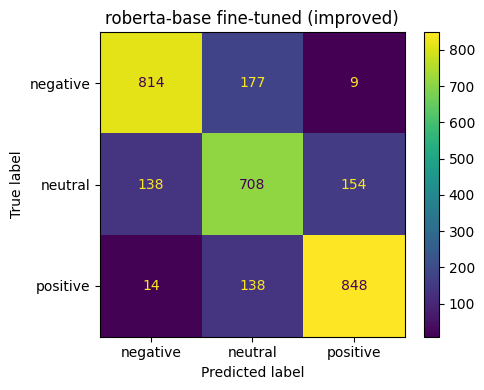

In [48]:
# Confusion matrix for improved model
cm = confusion_matrix(y_test, improved_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[LABEL_MAP[i] for i in sorted(LABEL_MAP)]
)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(values_format="d", ax=ax)
plt.title(f"{IMPROVED_MODEL_NAME} fine-tuned (improved)")
plt.tight_layout()
plt.show()

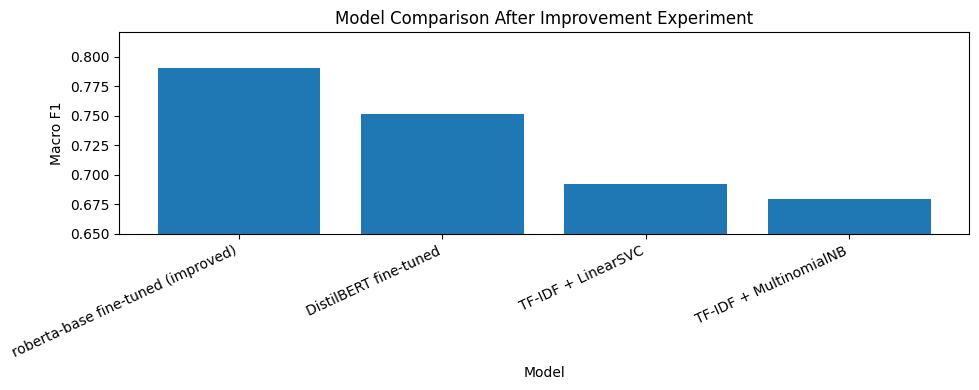

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted
0,roberta-base fine-tuned (improved),0.790,0.7912,0.790,0.7905,0.7912,0.790,0.7905
1,DistilBERT fine-tuned,0.750,0.7543,0.750,0.7517,0.7543,0.750,0.7517
2,TF-IDF + LinearSVC,0.693,0.6911,0.693,0.6918,0.6911,0.693,0.6918
3,TF-IDF + MultinomialNB,0.677,0.6873,0.677,0.6799,0.6873,0.677,0.6799


In [49]:
# Final comparison including the improvement experiment
plot_df = results_df.sort_values("F1_macro", ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(plot_df["Model"], plot_df["F1_macro"])
plt.ylim(max(0.6, plot_df["F1_macro"].min() - 0.03), min(1.0, plot_df["F1_macro"].max() + 0.03))
plt.title("Model Comparison After Improvement Experiment")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

results_df

## 9. Business Interpretation Guide

The results of this study can be used to answer key business questions in the hospitality and service industry:

- Which model most effectively identifies **dissatisfied customers** who may require intervention?
- To what extent is the **neutral class truly informative**, versus representing ambiguity or mixed sentiment?
- What linguistic patterns or phrases are associated with **positive and negative customer experiences**?
- Which types of misclassification errors would have the **highest business impact**?

### Practical Applications

The sentiment classification models can support several real-world use cases:

- **Customer recovery**: Automatically route negative reviews to support teams for timely resolution  
- **Service quality monitoring**: Aggregate and summarize recurring complaints or praise across locations  
- **Trend analysis**: Track sentiment shifts over time to evaluate operational changes or campaigns  
- **Customer conversion**: Identify neutral reviews as opportunities for targeted engagement or improvement  

### Key Insights from Model Performance

1. **Model performance trade-offs**  
   Classical models such as Naive Bayes and Linear SVM are computationally efficient and perform well on clearly polarized sentiment. However, they struggle with nuanced or context-dependent language. Transformer-based models are better suited for capturing these subtleties due to their contextual representations.

2. **Operational trade-offs**  
   In practice, model selection depends on business priorities. For example, organizations may prioritize **high recall for negative sentiment** to ensure that dissatisfied customers are not overlooked, even at the cost of increased false positives.

3. **Limitations**  
   Star ratings are an imperfect proxy for sentiment, as they may not fully reflect the tone or intent of the written review. Additionally, the use of **balanced sampling** in this study improves evaluation fairness but does not reflect real-world class distributions, where positive reviews are often dominant.

4. **Future directions**  
   Potential improvements include:
   - **Aspect-based sentiment analysis** to identify sentiment toward specific attributes (e.g., service, price, ambiance)  
   - **Domain-specific fine-tuning** to better capture industry language  
   - **Cost-sensitive learning** to align model optimization with business impact  
   - **Explainable AI techniques** to improve transparency and trust in model predictions  
   - **Multilingual models** to support broader and more diverse customer bases  

In [ ]:
# Save final results to CSV for reporting
results_df.to_csv("sentiment_model_comparison.csv", index=False)
print("Saved sentiment_model_comparison.csv")
results_df
